In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sys
import os

sys.path.append('..')
os.chdir('..')  

from src.utils.config_loader import load_config

config = load_config("configs/data_config.yaml")
print("Config loaded successfully ✅")

https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Electronics.jsonl.gz
Config loaded successfully ✅


In [2]:
# Load ratings data
raw_path = config['paths']['raw_data']

df_ratings = pd.read_csv(raw_path + "Electronics_ratings.csv")

print(f"Shape: {df_ratings.shape}")
print(f"\nColumns: {df_ratings.columns.tolist()}")
print(f"\nFirst 5 rows:")
df_ratings.head()

Shape: (100000, 10)

Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

First 5 rows:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


In [3]:
# Basic info about the data
print("=== Data Types ===")
print(df_ratings.dtypes)

print("\n=== Missing Values ===")
print(df_ratings.isnull().sum())

print("\n=== Rating Distribution ===")
print(df_ratings['rating'].value_counts().sort_index())

=== Data Types ===
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

=== Missing Values ===
rating                0
title                12
text                 12
images                0
asin                  0
parent_asin           0
user_id               0
timestamp             0
helpful_vote          0
verified_purchase     0
dtype: int64

=== Rating Distribution ===
rating
1.0     8006
2.0     4301
3.0     7131
4.0    15191
5.0    65371
Name: count, dtype: int64


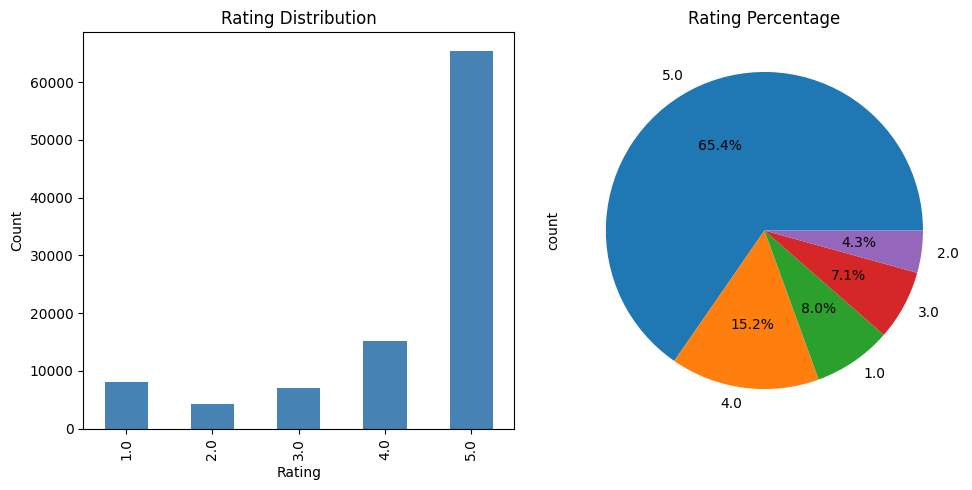

In [4]:
# Rating Distribution Plot
plt.figure(figsize=(10, 5))

# Plot 1 - Count
plt.subplot(1, 2, 1)
df_ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

# Plot 2 - Percentage
plt.subplot(1, 2, 2)
df_ratings['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Rating Percentage')

plt.tight_layout()
plt.show()

In [5]:
# User Activity Analysis
print("=== Users Stats ===")
user_activity = df_ratings['user_id'].value_counts()

print(f"Total unique users:    {df_ratings['user_id'].nunique()}")
print(f"Total unique items:    {df_ratings['asin'].nunique()}")
print(f"Max reviews per user:  {user_activity.max()}")
print(f"Min reviews per user:  {user_activity.min()}")
print(f"Avg reviews per user:  {user_activity.mean():.2f}")


=== Users Stats ===
Total unique users:    15322
Total unique items:    66260
Max reviews per user:  820
Min reviews per user:  1
Avg reviews per user:  6.53


In [6]:
print("=== Activity Distribution ===")
print(user_activity.value_counts().head(10))

=== Activity Distribution ===
count
1     4608
2     2690
3     1815
4     1218
5      932
6      637
7      512
8      411
9      314
10     257
Name: count, dtype: int64


Text(0, 0.5, 'Number of Users')

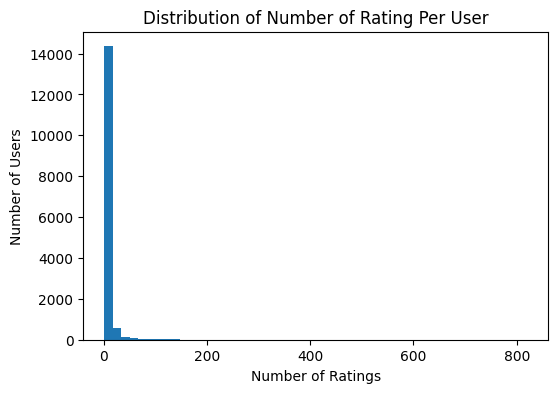

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(user_activity, bins=50)
plt.title("Distribution of Number of Rating Per User")
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')


In [8]:
df_ratings['timestamp'] = pd.to_datetime(df_ratings['timestamp'], unit='ms', errors='coerce')
df_ratings['timestamp'].head()

0   2022-07-18 22:58:37.948
1   2020-06-20 18:42:29.731
2   2018-04-07 09:23:37.534
3   2010-11-20 18:41:35.000
4   2023-02-17 02:39:41.238
Name: timestamp, dtype: datetime64[ns]

In [10]:
df_ratings.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True


In [11]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             100000 non-null  float64       
 1   title              99988 non-null   object        
 2   text               99988 non-null   object        
 3   images             100000 non-null  object        
 4   asin               100000 non-null  object        
 5   parent_asin        100000 non-null  object        
 6   user_id            100000 non-null  object        
 7   timestamp          100000 non-null  datetime64[ns]
 8   helpful_vote       100000 non-null  int64         
 9   verified_purchase  100000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 7.0+ MB


In [12]:
df_ratings.describe()

,rating,timestamp,helpful_vote
count,100000.000000,100000,100000.000000
mean,4.256200,2018-11-10 08:50:03.989504768,1.594510
min,1.000000,2000-10-07 14:21:50,0.000000
25%,4.000000,2016-10-28 23:33:19,0.000000
50%,5.000000,2019-07-15 21:27:28.495499776,0.000000
75%,5.000000,2021-03-29 14:07:29.684249856,1.000000
max,5.000000,2023-03-18 02:35:08.237000,6386.000000
std,1.245784,NaN,27.818478


Text(0, 0.5, 'HelpFul Votes')

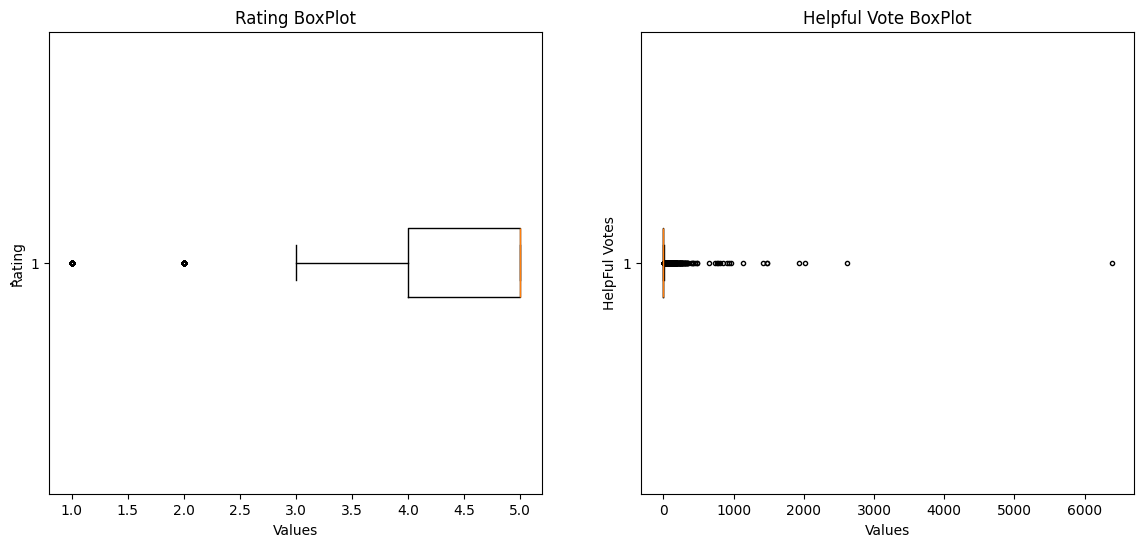

In [18]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.boxplot(df_ratings['rating'], vert=False, flierprops=dict(marker='o', markersize=3))
plt.title('Rating BoxPlot')
plt.xlabel('Values')
plt.ylabel('ٌRating')

plt.subplot(1, 2, 2)
plt.boxplot(df_ratings['helpful_vote'], vert=False, flierprops=dict(marker='o', markersize=3))
plt.title('Helpful Vote BoxPlot')
plt.xlabel('Values')
plt.ylabel('HelpFul Votes')

In [19]:
Q1 = df_ratings['helpful_vote'].quantile(0.25)
Q3 = df_ratings['helpful_vote'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_ratings[df_ratings['helpful_vote'] > Q3 + IQR * 1.5]
print(f"Outliers count: {len(outliers)}")
print(f"Outliers %: {len(outliers)/len(df_ratings)*100:.2f}%")

Outliers count: 8789
Outliers %: 8.79%


In [20]:
cap_value = Q3 + 1.5 * IQR
df_ratings['helpful_vote'] = df_ratings['helpful_vote'].clip(upper=cap_value)

In [21]:
Q1 = df_ratings['helpful_vote'].quantile(0.25)
Q3 = df_ratings['helpful_vote'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_ratings[df_ratings['helpful_vote'] > Q3 + IQR * 1.5]
print(f"Outliers count: {len(outliers)}")
print(f"Outliers %: {len(outliers)/len(df_ratings)*100:.2f}%")

Outliers count: 0
Outliers %: 0.00%


In [ ]:
df_ratings[df_ratings['title'].isnull()]


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
8049,1.0,NaN,NaN,[],B07GW9TJ3G,B07GW9TJ3G,AFVWRJSFTXSLWZUPRKKTVPY5JQRA,2022-04-24 14:40:18.350,0.0,True
8994,5.0,NaN,Great production,[],B0825TN7N8,B0859VXQF9,AE36THZQWROP2Z74SSA774SF36QQ,2021-05-04 20:45:52.632,0.0,True
10406,1.0,NaN,Returned item,[],B008I64JHS,B008I64JHS,AEZHRMVXXEGT4LCKGDCWWCA6ME7Q,2018-11-09 23:53:53.080,0.0,True
10728,5.0,NaN,NaN,[],B0916TKFF2,B0BK6PF1RH,AESWXC2XJZFCPL3FQDJ5MCIG3ADQ,2023-02-17 19:27:39.631,0.0,True
49364,1.0,NaN,No yood,[],B07415M2XR,B07415M2XR,AHSPF6FHGLVT7D7UTCXTMYQXGXWQ,2019-03-23 21:51:58.561,0.0,True
50957,4.0,NaN,NaN,[],B076FPGWNZ,B0BGS23YKX,AFIXQFQYAIQYDNGJXKYHCDJXJK7Q,2019-10-24 02:01:43.349,0.0,True
50958,4.0,NaN,NaN,[],B003NR57BY,B003NR57BY,AFIXQFQYAIQYDNGJXKYHCDJXJK7Q,2019-08-25 01:24:03.045,0.0,True
50959,5.0,NaN,NaN,[],B00KYK2ABI,B0BJW2XLMR,AFIXQFQYAIQYDNGJXKYHCDJXJK7Q,2018-10-19 16:17:17.455,0.0,True
50960,4.0,NaN,NaN,[],B07F12JLXS,B07F12JLXS,AFIXQFQYAIQYDNGJXKYHCDJXJK7Q,2018-09-27 00:18:57.017,0.0,True
53745,5.0,NaN,For my nephew... Recent cinematography grad......,[],B06XB87MDK,B06XB87MDK,AEYFUZ2WMRQKZGCDV5POYHNZMTNQ,2018-02-28 13:36:34.701,0.0,True


In [29]:
df_ratings.dropna(subset=['title', 'text'], inplace=True)

In [30]:
df_ratings[df_ratings['title'].isnull()]
df_ratings[df_ratings['text'].isnull()]

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase


In [31]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99982 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             99982 non-null  float64       
 1   title              99982 non-null  object        
 2   text               99982 non-null  object        
 3   images             99982 non-null  object        
 4   asin               99982 non-null  object        
 5   parent_asin        99982 non-null  object        
 6   user_id            99982 non-null  object        
 7   timestamp          99982 non-null  datetime64[ns]
 8   helpful_vote       99982 non-null  float64       
 9   verified_purchase  99982 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(6)
memory usage: 7.7+ MB


In [33]:
df_ratings.duplicated().value_counts()

False    99970
True        12
Name: count, dtype: int64

In [34]:
df_ratings.duplicated().sum()

np.int64(12)

In [35]:
df_ratings.duplicated(subset=['user_id', 'asin']).sum()

np.int64(12)

In [36]:
df_ratings.drop_duplicates(inplace=True)

In [37]:
df_ratings.duplicated().sum()

np.int64(0)

In [38]:
df_ratings.duplicated(subset=['user_id', 'asin']).sum()

np.int64(0)

In [39]:
print(len(df_ratings))

99970


In [41]:
df_ratings['timestamp'].dt.year.value_counts().sort_index()

timestamp
2000        1
2001        6
2002       19
2003       16
2004       33
2005       54
2006       67
2007      183
2008      268
2009      326
2010      563
2011     1084
2012     1701
2013     3254
2014     4623
2015     6366
2016     7822
2017     7888
2018     9267
2019    13509
2020    14092
2021    13219
2022    12878
2023     2731
Name: count, dtype: int64

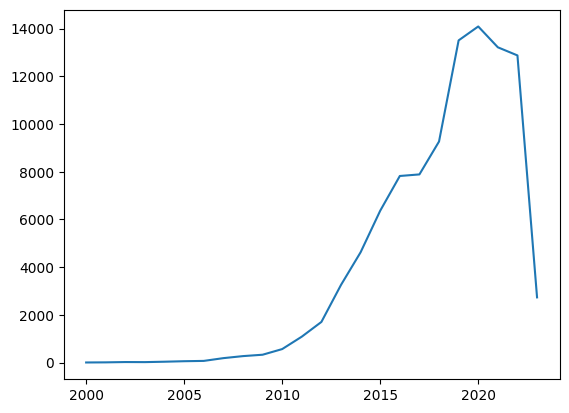

In [42]:
time_curve = df_ratings['timestamp'].dt.year.value_counts().sort_index()
plt.plot(time_curve.index, time_curve.values)

In [ ]:
n_users = df_ratings['user_id'].nunique()
n_items = df_ratings['asin'].nunique()
n_ratings = len(df_ratings)

sparsity = (1 - n_ratings / (n_users * n_items)) * 100
print(f"Sparsity: {sparsity:.2f}%")
# # Sparsity = 99.99% - This is normal for recommendation systems
# Solution: Matrix Factorization handles sparse data efficiently

Sparsity: 99.99%


In [ ]:
# # TODO: Use time-based train/test split
# Train: before 2022
# Test:  2022 onwards

In [ ]:
# TODO: Spam Detection in Preprocessing
# 1. Remove users with > 5 reviews per day
# 2. Check inter-review time - if seconds apart = bot

In [9]:
# # 1. ترتيب البيانات
# df = df_ratings.sort_values(['user_id', 'timestamp'])

# df['time_diff'] = df.groupby('user_id')['timestamp'].diff().dt.total_seconds()

# user_spam_check = df.groupby('user_id').agg({
#     'rating': 'count',
#     'time_diff': 'min'  
# }).rename(columns={'rating': 'total_ratings', 'time_diff': 'min_time_gap'})

# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 6))
# sns.scatterplot(data=user_spam_check, x='total_ratings', y='min_time_gap', alpha=0.6)

# plt.axhline(y=10, color='r', linestyle='--', label='Possible Bot (10s gap)')
# plt.yscale('log')
# plt.title('Spam Detection: Ratings Count vs Min Time Gap')
# plt.legend()
# plt.show()